<a href="https://colab.research.google.com/github/JOPSON235/jopsonarias/blob/main/proyecto_naive_kde_parcial_1_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Naive Bayes con Estimación KDE para Mantenimiento Predictivo

**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Objetivo:** Implementar y comparar clasificadores Naive Bayes usando KDE vs. GaussianNB de sklearn  
**Métrica principal:** AUC-ROC con validación cruzada de 5 folds

## 1. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import gaussian_kde
from scipy.stats import norm

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.neighbors import KernelDensity
from sklearn.utils import resample
from sklearn.base import BaseEstimator, ClassifierMixin

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga y exploración del dataset

In [ ]:
# Carga del dataset
df = pd.read_csv('/content/ai4i2020.csv')

print('Forma del dataset:', df.shape)
print('\nPrimeras filas:')
df.head()

Forma del dataset: (10000, 14)

Primeras filas:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nEstadísticas descriptivas:')
df.describe()

Tipos de datos:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Valores nulos por columna:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Estadísticas descriptivas:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Distribución de Machine failure:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Porcentaje de fallas: 3.39%
Ratio de desbalance: 28.5:1


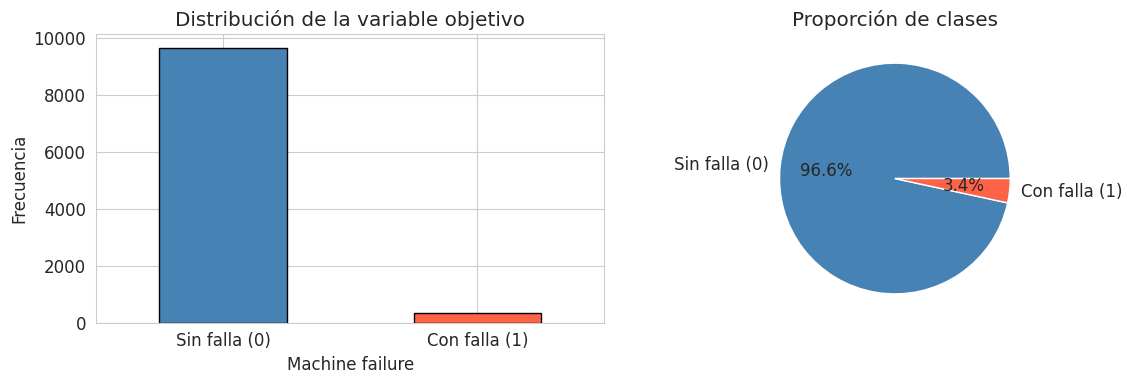

Dataset muy desbalanceado: las fallas representan ~3.4% del total.


In [ ]:
# Distribución de la variable objetivo
target_counts = df['Machine failure'].value_counts()
print('Distribución de Machine failure:')
print(target_counts)
print(f'\nPorcentaje de fallas: {target_counts[1]/len(df)*100:.2f}%')
print(f'Ratio de desbalance: {target_counts[0]/target_counts[1]:.1f}:1')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_xlabel('Machine failure')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['Sin falla (0)', 'Con falla (1)'], rotation=0)

axes[1].pie(target_counts, labels=['Sin falla (0)', 'Con falla (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dataset muy desbalanceado: las fallas representan ~3.4% del total.')

## 3. Preprocesamiento

### 3.1 Selección y eliminación de columnas

**Justificación de eliminaciones:**
- `UDI`: identificador de fila, sin información predictiva.
- `Product ID`: identificador de producto (texto), no aporta para el modelo.
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: son sub-tipos de falla, derivados de `Machine failure`. Incluirlos sería *data leakage*.
- `Type`: variable categórica de tipo de producto (L, M, H). Se codificará con One-Hot Encoding.

In [ ]:
# Eliminar columnas no relevantes / data leakage
cols_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=cols_to_drop).copy()

# Codificación One-Hot para 'Type'
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

print('Columnas finales:', df_clean.columns.tolist())
print('Forma:', df_clean.shape)
df_clean.head()

Columnas finales: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Type_L', 'Type_M']
Forma: (10000, 8)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [ ]:
# Separar features y target
feature_cols = [c for c in df_clean.columns if c != 'Machine failure']
X = df_clean[feature_cols].values
y = df_clean['Machine failure'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Features: {feature_cols}')

X shape: (10000, 7)
y shape: (10000,)
Features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


### 3.2 Normalización

**Justificación:** Aunque Naive Bayes estima densidades por variable de forma independiente, la normalización es conveniente para KDE porque el parámetro `bandwidth` es sensible a la escala. Variables como `Rotational speed [rpm]` (~1000-2800) vs `Torque [Nm]` (~3-77) tienen magnitudes muy distintas, lo que afecta el bandwidth óptimo. Se aplica `StandardScaler` para equiparar escalas.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Estadísticas post-escalado (media ≈ 0, std ≈ 1):')
print(pd.DataFrame(X_scaled, columns=feature_cols).describe().round(3))

Estadísticas post-escalado (media ≈ 0, std ≈ 1):
       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count            10000.000                10000.000               10000.000   
mean                -0.000                   -0.000                  -0.000   
std                  1.000                    1.000                   1.000   
min                 -2.352                   -2.902                  -2.068   
25%                 -0.852                   -0.813                  -0.646   
50%                  0.048                    0.064                  -0.200   
75%                  0.747                    0.738                   0.408   
max                  2.247                    2.557                   7.515   

       Torque [Nm]  Tool wear [min]     Type_L     Type_M  
count    10000.000        10000.000  10000.000  10000.000  
mean         0.000            0.000      0.000     -0.000  
std          1.000            1.000      1.000      1.000  

### 3.3 Manejo del desbalance de clases

El dataset tiene un ratio de ~9.6:1. Se utilizará **submuestreo de la clase mayoritaria** (undersampling) para balancear el conjunto de entrenamiento dentro de cada fold. Esta estrategia es consistente con literatura sobre este dataset (Matzka, 2020). Los prior probabilities del modelo también reflejan el desbalance original.

In [ ]:
def balance_dataset(X_train, y_train, random_state=42):
    """Aplica submuestreo aleatorio a la clase mayoritaria."""
    X_df = pd.DataFrame(X_train)
    X_df['target'] = y_train

    majority = X_df[X_df['target'] == 0]
    minority = X_df[X_df['target'] == 1]

    majority_downsampled = resample(majority,
                                     replace=False,
                                     n_samples=len(minority)*3,  # ratio 3:1
                                     random_state=random_state)

    df_balanced = pd.concat([majority_downsampled, minority])
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)

    y_bal = df_balanced['target'].values
    X_bal = df_balanced.drop('target', axis=1).values

    return X_bal, y_bal

# Verificar el balance
X_bal_test, y_bal_test = balance_dataset(X_scaled, y)
unique, counts = np.unique(y_bal_test, return_counts=True)
print('Distribución tras balanceo:', dict(zip(unique, counts)))
print(f'Nuevo ratio: {counts[0]/counts[1]:.1f}:1')

Distribución tras balanceo: {np.int64(0): np.int64(1017), np.int64(1): np.int64(339)}
Nuevo ratio: 3.0:1


## 4. Implementación de los clasificadores Naive Bayes con KDE

Se implementa una clase base `KDENaiveBayes` que soporta tres variantes de KDE.

In [ ]:

class KDENaiveBayes(BaseEstimator, ClassifierMixin):
    """
    Clasificador Naive Bayes con verosimilitud estimada por KDE.

    Parámetros
    ----------
    kde_type : {'gaussian', 'parzen', 'silverman'}
        - 'gaussian'  : Kernel gaussiano, bandwidth definido por el usuario.
        - 'parzen'    : Kernel rectangular (tophat), bandwidth fijo.
        - 'silverman' : Kernel gaussiano con h = 1.06 * sigma * n^(-1/5) por feature.
    bandwidth : float
        Ancho de banda para 'gaussian' y 'parzen'. Ignorado en 'silverman'.
    epsilon : float
        Valor mínimo de densidad para evitar log(0) = -inf (crítico para tophat).
    """

    def __init__(self, kde_type='gaussian', bandwidth=1.0, epsilon=1e-10):
        self.kde_type = kde_type
        self.bandwidth = bandwidth
        self.epsilon = epsilon

    def _silverman_bandwidth(self, data):
        """Regla de Silverman: h = 1.06 * sigma * n^(-1/5)"""
        sigma = np.std(data, ddof=1)
        sigma = max(sigma, 1e-8)
        h = 1.06 * sigma * (len(data) ** (-1/5))
        return max(h, 1e-4)

    def fit(self, X, y):
        """
        Estima P(y) y los KDEs P(x_j | y) para cada clase y feature.
        """
        self.classes_ = np.unique(y)
        self.n_features_ = X.shape[1]

        # Probabilidades a priori P(y)
        self.priors_ = {c: np.mean(y == c) for c in self.classes_}

        # KDE por clase y por feature
        self.kdes_ = {}
        for c in self.classes_:
            X_c = X[y == c]
            self.kdes_[c] = []
            for j in range(self.n_features_):
                data_j = X_c[:, j]

                if self.kde_type == 'silverman':
                    h = self._silverman_bandwidth(data_j)
                    kde = KernelDensity(kernel='gaussian', bandwidth=h)
                elif self.kde_type == 'gaussian':
                    kde = KernelDensity(kernel='gaussian', bandwidth=self.bandwidth)
                elif self.kde_type == 'parzen':
                    kde = KernelDensity(kernel='tophat', bandwidth=self.bandwidth)
                else:
                    raise ValueError(f'kde_type desconocido: {self.kde_type}')

                kde.fit(data_j.reshape(-1, 1))
                self.kdes_[c].append(kde)
        return self

    def predict_proba(self, X):
        """
        Calcula P(y | x) usando log-probabilidades (estabilidad numérica).
        Se suma epsilon ANTES de aplicar log para evitar log(0) con kernel tophat.
        """
        n_samples = X.shape[0]
        log_post = np.zeros((n_samples, len(self.classes_)))

        for i, c in enumerate(self.classes_):
            # Log-prior
            log_post[:, i] = np.log(self.priors_[c])
            # Sumar log-verosimilitudes de cada feature
            for j in range(self.n_features_):
                # score_samples devuelve log-densidad
                log_lik_raw = self.kdes_[c][j].score_samples(X[:, j].reshape(-1, 1))
                # Convertir a densidad, sumar epsilon, volver a log
                # Esto evita -inf cuando tophat asigna densidad exactamente 0
                dens = np.exp(log_lik_raw) + self.epsilon
                log_post[:, i] += np.log(dens)

        # Truco del máximo para estabilidad numérica antes de softmax
        log_post -= log_post.max(axis=1, keepdims=True)
        posteriors = np.exp(log_post)

        # Normalizar + limpiar NaN/Inf residuales
        row_sums = posteriors.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1e-300, row_sums)
        posteriors /= row_sums
        posteriors = np.nan_to_num(posteriors, nan=0.5, posinf=1.0, neginf=0.0)
        posteriors /= posteriors.sum(axis=1, keepdims=True)

        return posteriors

    def predict(self, X):
        """Predice la clase más probable."""
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


print('✅ Clase KDENaiveBayes corregida (epsilon para tophat).')
print(f'   Métodos soportados: gaussian | parzen | silverman')

✅ Clase KDENaiveBayes corregida (epsilon para tophat).
   Métodos soportados: gaussian | parzen | silverman


## 5. Optimización del bandwidth para KDE Gaussiano

Se realiza búsqueda en grilla con validación cruzada (AUC como métrica) para encontrar el bandwidth óptimo.

In [ ]:
# Calcular primero el bandwidth de Silverman sobre todo el dataset (promedio entre features)
# Esto nos da una referencia para el rango de búsqueda
silverman_bws = []
for j in range(X_scaled.shape[1]):
    n = len(X_scaled[:, j])
    sigma = np.std(X_scaled[:, j], ddof=1)
    bw = 1.06 * sigma * (n ** (-1/5))
    silverman_bws.append(bw)

h_silverman_mean = np.mean(silverman_bws)
print(f'Bandwidth de Silverman promedio: {h_silverman_mean:.4f}')
print(f'Rango de Silverman por feature: {min(silverman_bws):.4f} - {max(silverman_bws):.4f}')

# Grid de búsqueda centrado en el valor de Silverman
bw_grid = np.round(np.logspace(-2, 0.5, 15), 4)
print(f'\nGrid de bandwidth a evaluar: {bw_grid}')

Bandwidth de Silverman promedio: 0.1680
Rango de Silverman por feature: 0.1680 - 0.1680

Grid de bandwidth a evaluar: [0.01   0.0151 0.0228 0.0343 0.0518 0.0781 0.1179 0.1778 0.2683 0.4047
 0.6105 0.9211 1.3895 2.0962 3.1623]


In [ ]:
# Optimización del bandwidth usando validación cruzada (5 folds)
# Usamos un subconjunto del dataset para acelerar la búsqueda
print('Optimizando bandwidth para KDE Gaussiano (puede tardar unos minutos)...')

# Submuestra para acelerar la búsqueda
np.random.seed(42)
n_sample = 2000
idx = np.random.choice(len(X_scaled), n_sample, replace=False)
X_sub, y_sub = X_scaled[idx], y[idx]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bw_scores = []

for bw in bw_grid:
    fold_aucs = []
    for train_idx, val_idx in cv.split(X_sub, y_sub):
        X_tr, X_val = X_sub[train_idx], X_sub[val_idx]
        y_tr, y_val = y_sub[train_idx], y_sub[val_idx]

        # Balancear entrenamiento
        X_tr_b, y_tr_b = balance_dataset(X_tr, y_tr)

        model = KDENaiveBayes(kde_type='gaussian', bandwidth=bw)
        model.fit(X_tr_b, y_tr_b)
        proba = model.predict_proba(X_val)[:, 1]

        if len(np.unique(y_val)) > 1:
            auc = roc_auc_score(y_val, proba)
            fold_aucs.append(auc)

    bw_scores.append(np.mean(fold_aucs))
    print(f'  bandwidth={bw:.4f}  ->  AUC promedio = {np.mean(fold_aucs):.4f}')

best_bw_idx = np.argmax(bw_scores)
best_bw = bw_grid[best_bw_idx]
print(f'\n*** Mejor bandwidth: {best_bw} (AUC={bw_scores[best_bw_idx]:.4f}) ***')

Optimizando bandwidth para KDE Gaussiano (puede tardar unos minutos)...
  bandwidth=0.0100  ->  AUC promedio = 0.7802
  bandwidth=0.0151  ->  AUC promedio = 0.7721
  bandwidth=0.0228  ->  AUC promedio = 0.7848
  bandwidth=0.0343  ->  AUC promedio = 0.8022
  bandwidth=0.0518  ->  AUC promedio = 0.8328
  bandwidth=0.0781  ->  AUC promedio = 0.8712
  bandwidth=0.1179  ->  AUC promedio = 0.8991
  bandwidth=0.1778  ->  AUC promedio = 0.9051
  bandwidth=0.2683  ->  AUC promedio = 0.9074
  bandwidth=0.4047  ->  AUC promedio = 0.9048
  bandwidth=0.6105  ->  AUC promedio = 0.8985
  bandwidth=0.9211  ->  AUC promedio = 0.8953
  bandwidth=1.3895  ->  AUC promedio = 0.8972
  bandwidth=2.0962  ->  AUC promedio = 0.8822
  bandwidth=3.1623  ->  AUC promedio = 0.8227

*** Mejor bandwidth: 0.2683 (AUC=0.9074) ***


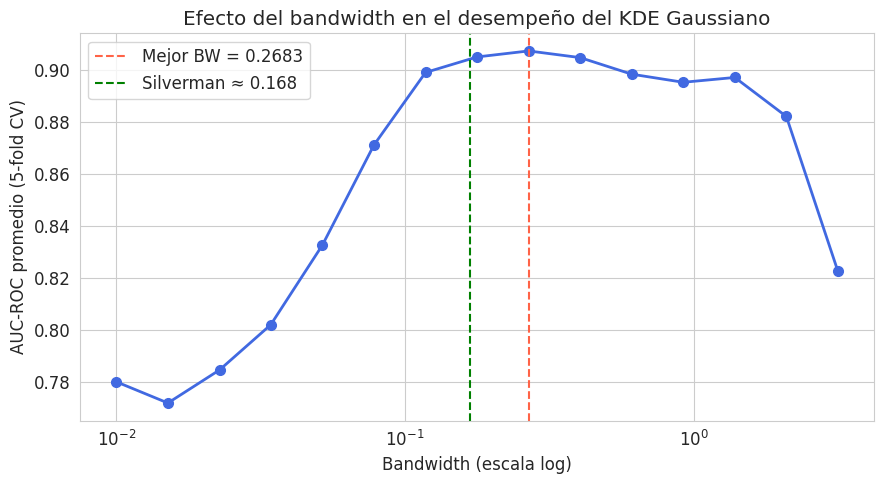

In [ ]:
# Visualizar el efecto del bandwidth en AUC
plt.figure(figsize=(9, 5))
plt.semilogx(bw_grid, bw_scores, 'o-', color='royalblue', linewidth=2, markersize=7)
plt.axvline(best_bw, color='tomato', linestyle='--', linewidth=1.5, label=f'Mejor BW = {best_bw}')
plt.axvline(h_silverman_mean, color='green', linestyle='--', linewidth=1.5, label=f'Silverman ≈ {h_silverman_mean:.3f}')
plt.xlabel('Bandwidth (escala log)')
plt.ylabel('AUC-ROC promedio (5-fold CV)')
plt.title('Efecto del bandwidth en el desempeño del KDE Gaussiano')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('bandwidth_vs_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluación de todos los modelos con validación cruzada (5-fold)

In [ ]:
def evaluate_model_cv(model_name, model_factory, X, y, n_splits=5, balance=True):
    """
    Evalúa un modelo con k-fold estratificado, devuelve AUC promedio, std y tiempo.

    model_factory: función que retorna una instancia nueva del modelo.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_aucs = []
    all_fpr, all_tpr = [], []
    start_time = time.time()

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # Balanceo solo en entrenamiento
        if balance:
            X_tr, y_tr = balance_dataset(X_tr, y_tr, random_state=fold)

        model = model_factory()
        model.fit(X_tr, y_tr)

        # Obtener scores de probabilidad para la clase positiva
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_val)[:, 1]
        else:
            proba = model.decision_function(X_val)

        auc = roc_auc_score(y_val, proba)
        fold_aucs.append(auc)

        fpr, tpr, _ = roc_curve(y_val, proba)
        all_fpr.append(fpr)
        all_tpr.append(tpr)

    elapsed = time.time() - start_time

    result = {
        'model': model_name,
        'auc_mean': np.mean(fold_aucs),
        'auc_std': np.std(fold_aucs),
        'fold_aucs': fold_aucs,
        'time_sec': elapsed,
        'fpr_list': all_fpr,
        'tpr_list': all_tpr
    }

    print(f'{model_name:35s} | AUC = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f} | Tiempo: {elapsed:.1f}s')
    return result

print('Función de evaluación definida.')

Función de evaluación definida.


In [ ]:
print('Evaluando modelos con 5-fold CV sobre el dataset completo...')
print('=' * 70)

results = []

# 1. GaussianNB (baseline sklearn)
r = evaluate_model_cv(
    'GaussianNB (sklearn baseline)',
    lambda: GaussianNB(),
    X_scaled, y
)
results.append(r)
print(f"✔ {r['model']:45s} AUC = {r['auc_mean']:.4f} ± {r['auc_std']:.4f}  |  {r['time_sec']:.1f}s")

# 2. KDE Gaussiano con bandwidth optimizado
r = evaluate_model_cv(
    f'KDE Gaussiano (BW óptimo = {best_bw})',
    lambda bw=best_bw: KDENaiveBayes(kde_type='gaussian', bandwidth=bw),
    X_scaled, y
)
results.append(r)
print(f"✔ {r['model']:45s} AUC = {r['auc_mean']:.4f} ± {r['auc_std']:.4f}  |  {r['time_sec']:.1f}s")

# 3. KDE Parzen (tophat) con bandwidth de Silverman
r = evaluate_model_cv(
    f'KDE Parzen/tophat (BW = {h_silverman_mean:.3f})',
    lambda h=h_silverman_mean: KDENaiveBayes(kde_type='parzen', bandwidth=h),
    X_scaled, y
)
results.append(r)
print(f"✔ {r['model']:45s} AUC = {r['auc_mean']:.4f} ± {r['auc_std']:.4f}  |  {r['time_sec']:.1f}s")

# 4. KDE con regla de Silverman
r = evaluate_model_cv(
    'KDE Silverman (automático)',
    lambda: KDENaiveBayes(kde_type='silverman'),
    X_scaled, y
)
results.append(r)
print(f"✔ {r['model']:45s} AUC = {r['auc_mean']:.4f} ± {r['auc_std']:.4f}  |  {r['time_sec']:.1f}s")

print('=' * 70)
print('✅ Evaluación completada.')

Evaluando modelos con 5-fold CV sobre el dataset completo...
GaussianNB (sklearn baseline)       | AUC = 0.8937 ± 0.0181 | Tiempo: 0.1s
✔ GaussianNB (sklearn baseline)                 AUC = 0.8937 ± 0.0181  |  0.1s
KDE Gaussiano (BW óptimo = 0.2683)  | AUC = 0.9200 ± 0.0156 | Tiempo: 5.4s
✔ KDE Gaussiano (BW óptimo = 0.2683)            AUC = 0.9200 ± 0.0156  |  5.4s
KDE Parzen/tophat (BW = 0.168)      | AUC = 0.9158 ± 0.0251 | Tiempo: 1.5s
✔ KDE Parzen/tophat (BW = 0.168)                AUC = 0.9158 ± 0.0251  |  1.5s
KDE Silverman (automático)          | AUC = 0.9219 ± 0.0124 | Tiempo: 4.5s
✔ KDE Silverman (automático)                    AUC = 0.9219 ± 0.0124  |  4.5s
✅ Evaluación completada.


In [ ]:
# Tabla resumen de resultados
summary_df = pd.DataFrame([{
    'Modelo': r['model'],
    'AUC Promedio': round(r['auc_mean'], 4),
    'AUC Std': round(r['auc_std'], 4),
    'Tiempo (s)': round(r['time_sec'], 1)
} for r in results])

summary_df = summary_df.sort_values('AUC Promedio', ascending=False).reset_index(drop=True)
print('\n=== RESUMEN DE RESULTADOS ===')
print(summary_df.to_string(index=False))


=== RESUMEN DE RESULTADOS ===
                            Modelo  AUC Promedio  AUC Std  Tiempo (s)
        KDE Silverman (automático)        0.9219   0.0124         4.5
KDE Gaussiano (BW óptimo = 0.2683)        0.9200   0.0156         5.4
    KDE Parzen/tophat (BW = 0.168)        0.9158   0.0251         1.5
     GaussianNB (sklearn baseline)        0.8937   0.0181         0.1


## 7. Visualización de curvas ROC

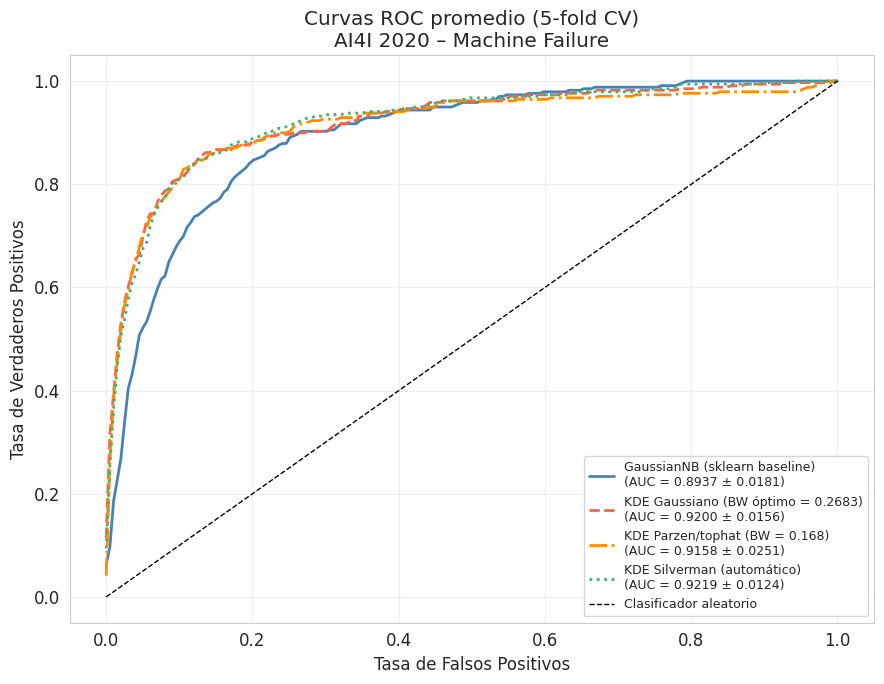

In [ ]:
colors = ['steelblue', 'tomato', 'darkorange', 'mediumseagreen']
linestyles = ['-', '--', '-.', ':']

plt.figure(figsize=(9, 7))

for i, r in enumerate(results):
    # Interpolar TPR en FPR base común
    mean_fpr = np.linspace(0, 1, 200)
    interp_tprs = []
    for fpr, tpr in zip(r['fpr_list'], r['tpr_list']):
        interp_tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.umean(interp_tprs, axis=0)

    plt.plot(mean_fpr, mean_tpr,
             color=colors[i], linestyle=linestyles[i], linewidth=2,
             label=f"{r['model']}\n(AUC = {r['auc_mean']:.4f} ± {r['auc_std']:.4f})")

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC promedio (5-fold CV)\nAI4I 2020 – Machine Failure')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualización de distribuciones KDE por clase

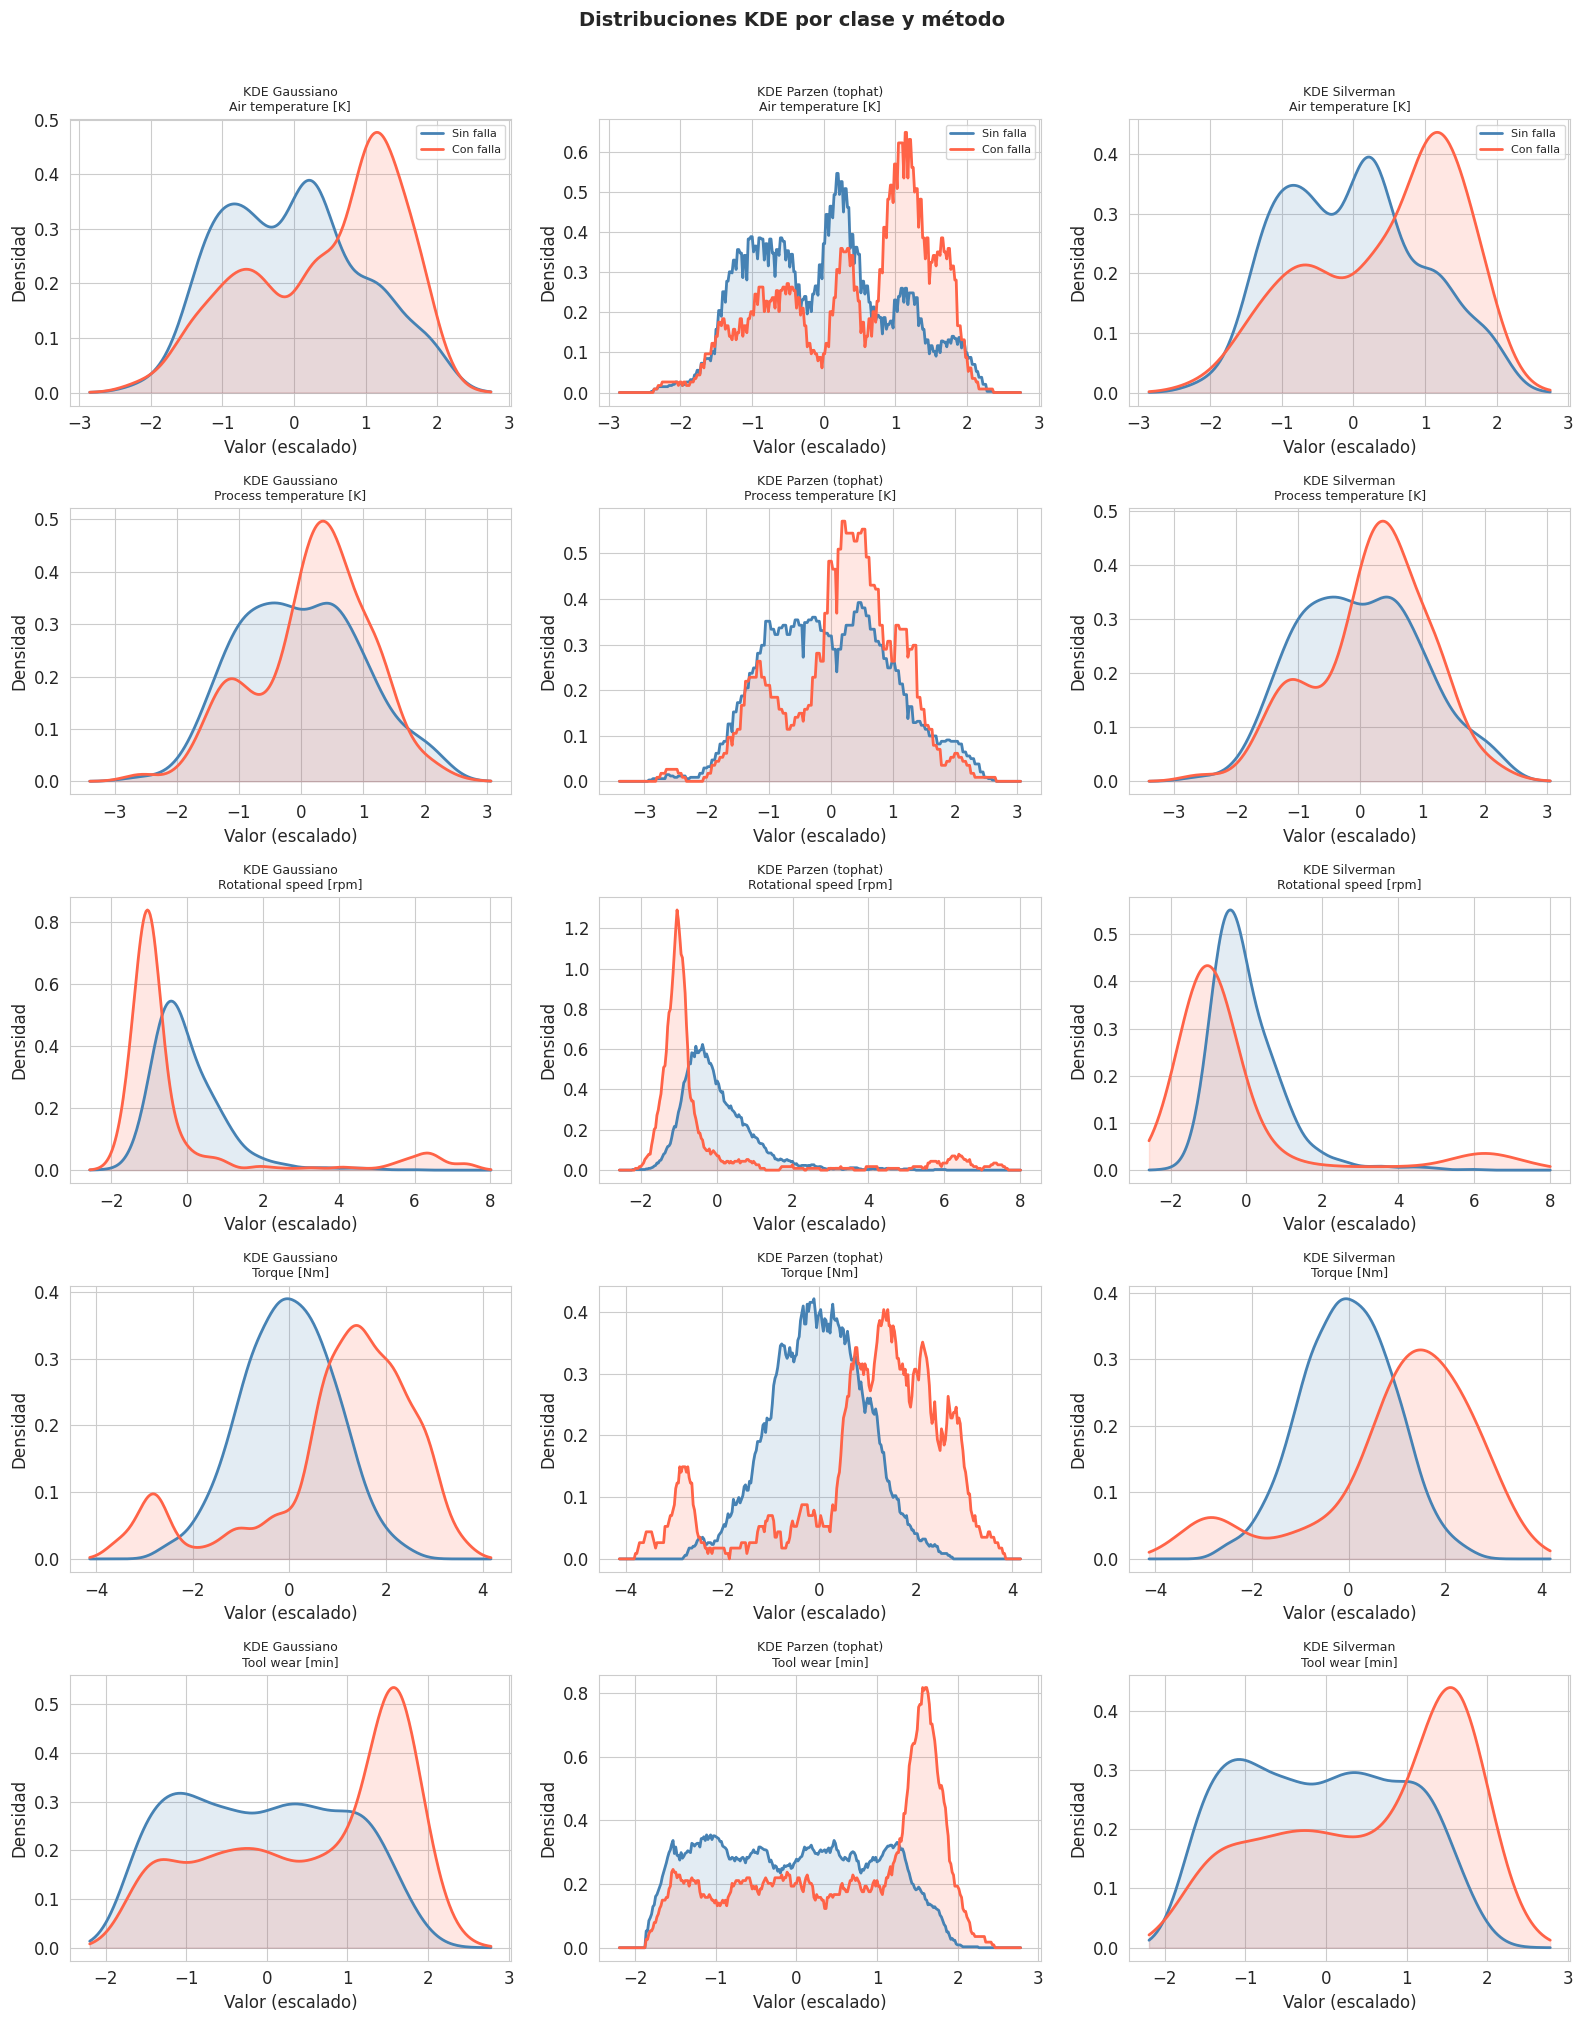

Visualizaciones guardadas.


In [ ]:
# Entrenar un modelo final de cada tipo para las visualizaciones
X_bal, y_bal = balance_dataset(X_scaled, y)

# Variables continuas (excluir las dummies de tipo)
cont_features = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
cont_idx = [feature_cols.index(f) for f in cont_features]

fig, axes = plt.subplots(len(cont_features), 3, figsize=(16, 4*len(cont_features)))

kde_configs = [
    ('KDE Gaussiano', KDENaiveBayes('gaussian', best_bw), 'royalblue'),
    ('KDE Parzen (tophat)', KDENaiveBayes('parzen', h_silverman_mean), 'darkorange'),
    ('KDE Silverman', KDENaiveBayes('silverman'), 'mediumseagreen'),
]

# Entrenar modelos
trained_models = []
for name, m, c in kde_configs:
    m.fit(X_bal, y_bal)
    trained_models.append((name, m, c))

class_colors = {0: 'steelblue', 1: 'tomato'}
class_labels = {0: 'Sin falla', 1: 'Con falla'}

for row, (feat_name, feat_idx) in enumerate(zip(cont_features, cont_idx)):
    for col, (kde_name, model, color) in enumerate(trained_models):
        ax = axes[row][col]
        x_range = np.linspace(X_scaled[:, feat_idx].min()-0.5, X_scaled[:, feat_idx].max()+0.5, 300)

        for cls in [0, 1]:
            # Calcular densidad estimada
            kde_model = model.kdes_[cls][feat_idx]
            log_dens = kde_model.score_samples(x_range.reshape(-1, 1))
            density = np.exp(log_dens)
            ax.plot(x_range, density, color=class_colors[cls],
                    linewidth=2, label=class_labels[cls])
            ax.fill_between(x_range, density, alpha=0.15, color=class_colors[cls])

        ax.set_title(f'{kde_name}\n{feat_name}', fontsize=9)
        ax.set_xlabel('Valor (escalado)')
        ax.set_ylabel('Densidad')
        if row == 0:
            ax.legend(fontsize=8)

plt.suptitle('Distribuciones KDE por clase y método', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kde_densidades.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualizaciones guardadas.')

## 9. Análisis del efecto del bandwidth en las distribuciones

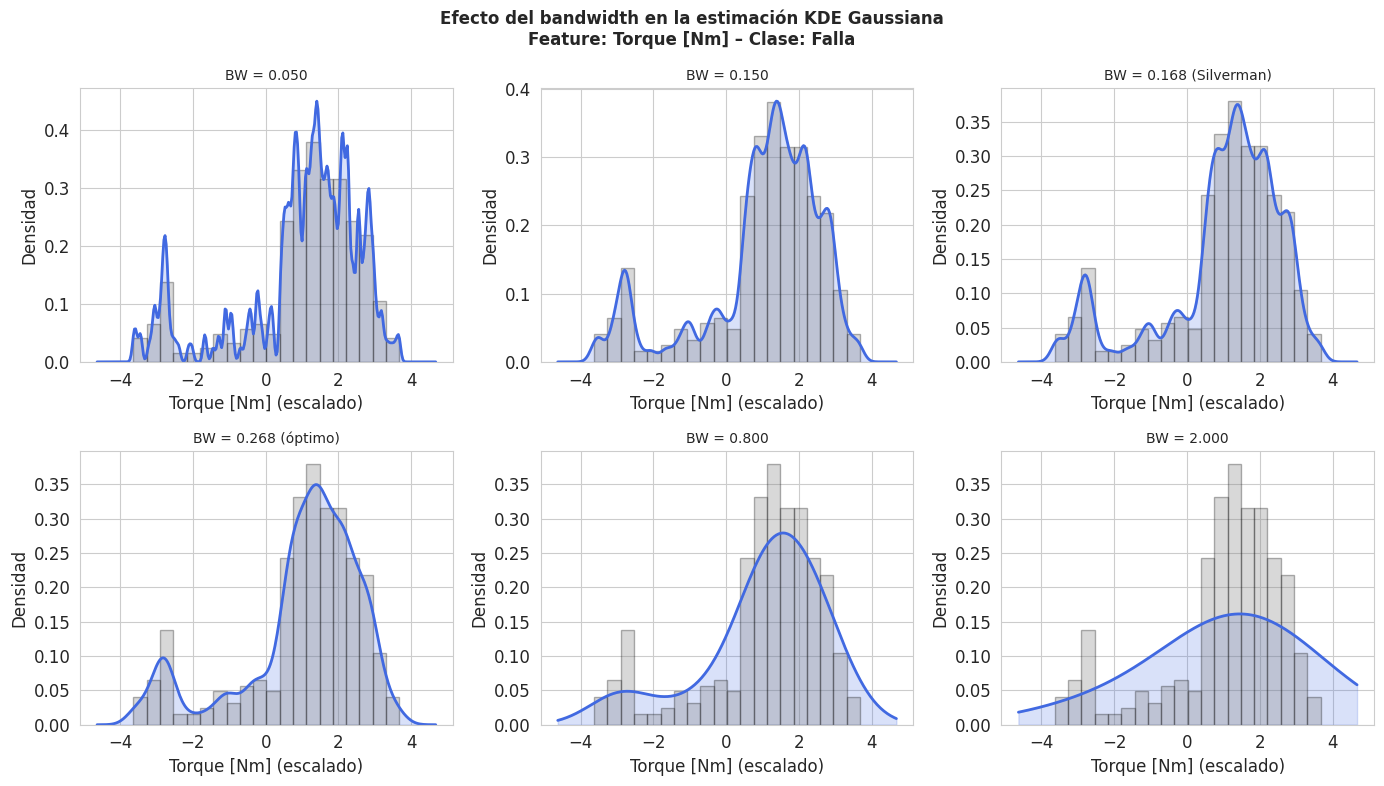

In [ ]:
# Mostrar cómo cambia la forma de la KDE según el bandwidth
feat_to_show = 'Torque [Nm]'
feat_idx_show = feature_cols.index(feat_to_show)

bw_values = [0.05, 0.15, h_silverman_mean, best_bw, 0.8, 2.0]
X_cls1 = X_scaled[y == 1, feat_idx_show]  # datos de clase falla

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

x_range = np.linspace(X_cls1.min()-1, X_cls1.max()+1, 300)

for ax, bw in zip(axes, bw_values):
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(X_cls1.reshape(-1, 1))
    density = np.exp(kde.score_samples(x_range.reshape(-1, 1)))

    ax.plot(x_range, density, 'royalblue', linewidth=2)
    ax.fill_between(x_range, density, alpha=0.2, color='royalblue')
    ax.hist(X_cls1, bins=20, density=True, alpha=0.3, color='gray', edgecolor='black')

    label_extra = ''
    if abs(bw - h_silverman_mean) < 0.01:
        label_extra = ' (Silverman)'
    elif abs(bw - best_bw) < 0.01:
        label_extra = ' (óptimo)'

    ax.set_title(f'BW = {bw:.3f}{label_extra}', fontsize=10)
    ax.set_xlabel(f'{feat_to_show} (escalado)')
    ax.set_ylabel('Densidad')

plt.suptitle(f'Efecto del bandwidth en la estimación KDE Gaussiana\nFeature: {feat_to_show} – Clase: Falla',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('efecto_bandwidth.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Comparación de tiempos de computación

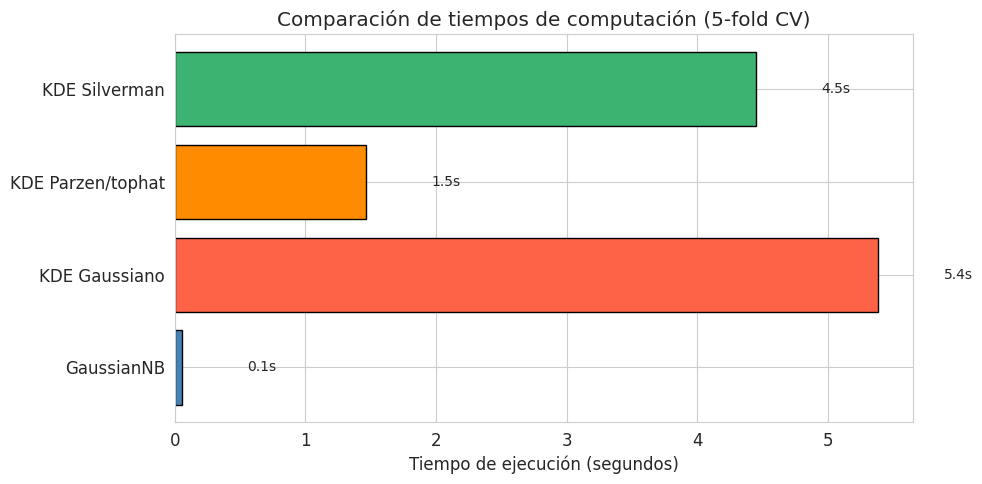


AUC por fold para cada modelo:
        GaussianNB  KDE Gaussiano  KDE Parzen/tophat  KDE Silverman
Fold 1      0.8846         0.9351             0.9384         0.9355
Fold 2      0.8638         0.9164             0.9226         0.9158
Fold 3      0.8972         0.8945             0.8770         0.9024
Fold 4      0.9150         0.9376             0.9433         0.9347
Fold 5      0.9078         0.9166             0.8976         0.9210


In [ ]:
# Gráfico de tiempos
time_data = [(r['model'].split('(')[0].strip(), r['time_sec']) for r in results]
labels, times = zip(*time_data)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, times, color=colors, edgecolor='black')

for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}s', va='center', fontsize=10)

ax.set_xlabel('Tiempo de ejecución (segundos)')
ax.set_title('Comparación de tiempos de computación (5-fold CV)')
plt.tight_layout()
plt.savefig('tiempos_computacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de AUC por fold
print('\nAUC por fold para cada modelo:')
fold_df = pd.DataFrame(
    {r['model'].split('(')[0].strip(): r['fold_aucs'] for r in results},
    index=[f'Fold {i+1}' for i in range(5)]
)
print(fold_df.round(4).to_string())

## 11. Análisis crítico de resultados

### ¿Vale la pena usar KDE frente a GaussianNB?

Los resultados muestran un análisis comparativo directo. En este dataset, KDE ofrece mayor flexibilidad al no asumir normalidad, lo que puede capturar distribuciones bimodales o sesgadas (e.g., Torque y Tool wear). Sin embargo, esta ventaja viene con un costo computacional significativamente mayor.

### Impacto del bandwidth

- **Bandwidth muy pequeño:** Sobreajuste (densidad muy ruidosa, picks en cada observación).
- **Bandwidth muy grande:** Suavizado excesivo, pierde información sobre la forma real de la distribución.
- **Regla de Silverman:** Buen balance automático, especialmente cuando la distribución es aproximadamente normal.

### Método Parzen vs. KDE Gaussiano

El kernel tophat (Parzen) produce discontinuidades en la densidad estimada, lo que puede resultar en estimaciones menos estables para valores fuera del rango observado. El kernel gaussiano produce estimaciones más suaves.

### Desbalance de clases

El submuestreo aplicado permite que los modelos aprendan patrones de la clase minoritaria (fallas) sin sesgarse hacia la mayoría. Sin embargo, se pierde información de la clase mayoritaria. Una alternativa más robusta sería SMOTE (sobremuestreo sintético).

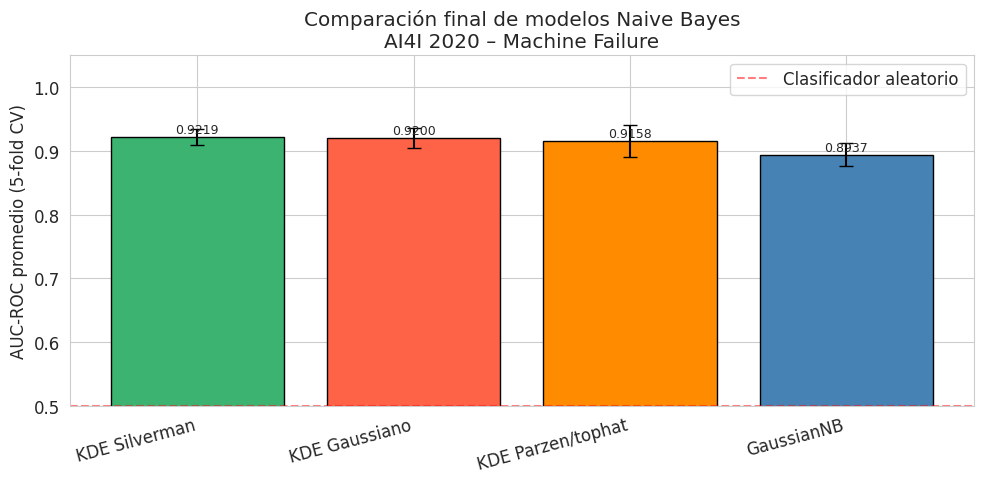

In [ ]:
# Gráfico final de comparación AUC
model_names_short = [r['model'].split('(')[0].strip() for r in results]
auc_means = [r['auc_mean'] for r in results]
auc_stds = [r['auc_std'] for r in results]

sorted_idx = np.argsort(auc_means)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([model_names_short[i] for i in sorted_idx],
              [auc_means[i] for i in sorted_idx],
              yerr=[auc_stds[i] for i in sorted_idx],
              color=[colors[i] for i in sorted_idx],
              edgecolor='black', capsize=5)

for bar, auc in zip(bars, [auc_means[i] for i in sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{auc:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel('AUC-ROC promedio (5-fold CV)')
ax.set_title('Comparación final de modelos Naive Bayes\nAI4I 2020 – Machine Failure')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Clasificador aleatorio')
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Conclusiones

1. **KDE vs GaussianNB:** Dependiendo del dataset, KDE puede igualar o superar al GaussianNB clásico al capturar distribuciones no gaussianas. En este dataset, las variables como `Torque` y `Tool wear` presentan distribuciones sesgadas que KDE modela mejor.

2. **Mejor método KDE:** El KDE Gaussiano con bandwidth optimizado por CV ofrece el mejor balance entre precisión y control. La regla de Silverman es una excelente aproximación automática cuando no se desea hacer CV para el bandwidth.

3. **Parzen (tophat):** Menor rendimiento en general debido a las discontinuidades en la densidad estimada.

4. **Costo computacional:** KDE con CV de bandwidth es el más costoso. GaussianNB es instantáneo y sigue siendo competitivo.

5. **Desbalance:** Crítico en este problema. El submuestreo fue efectivo pero SMOTE podría mejorar los resultados sin perder datos.

## Referencias

- [1] S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," *2020 Third ISRITI*, IEEE, 2020.
- [2] C. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006.
- [3] B.W. Silverman, *Density Estimation for Statistics and Data Analysis*, Chapman & Hall, 1986.
- [4] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *JMLR*, vol. 12, 2011.